**Part C - Evaluation**
--

---

For the evaluation part, we are encoding the records for all six models and their peformances.

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Load the MNIST Data
(x_train_full, y_train_full), (x_test, y_test_full) = mnist.load_data()
X = np.concatenate((x_train_full, x_test), axis=0)[:2000]
y = np.concatenate((y_train_full, y_test_full), axis=0)[:2000]

# 2. Reshape and Normalize
X = X.reshape(2000, -1)
X_norm = X / 255.0

# 3. Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X_norm, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

# 4. Setup variables and the print function for the metrics
classes = np.unique(y)
y_val_bin = label_binarize(y_val, classes=classes)

def print_metrics(model_name, y_true, y_pred, y_prob):
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_val_bin, y_prob, multi_class='ovr', average='macro'):.4f}\n")

print("Data is loaded and ready! You can now run your model cells.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data is loaded and ready! You can now run your model cells.


1 Logistic Regression
--
---

This calls a custom function (likely defined elsewhere in your script) to print out performance scores. It compares the model's guesses (logReg_pred) against the actual correct answers. This is applied to the rest of the models.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize, fit, and predict
logReg = LogisticRegression(max_iter=1000, random_state=42)
logReg.fit(X_train, y_train)

logReg_pred = logReg.predict(X_val)
logReg_prob = logReg.predict_proba(X_val) # Required for AUC-ROC

print_metrics("1. Logistic Regression", y_val, logReg_pred, logReg_prob)

--- 1. Logistic Regression ---
Accuracy:  0.9000
Precision: 0.8973
Recall:    0.8881
F1-Score:  0.8914
AUC-ROC:   0.9889



2 K-nearest Neighbors
--

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize with optimal k=5, fit, and predict
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_val)
knn_prob = knn.predict_proba(X_val) # Required for AUC-ROC

print_metrics("2. K-Nearest Neighbors (k=5)", y_val, knn_pred, knn_prob)

--- 2. K-Nearest Neighbors (k=5) ---
Accuracy:  0.9222
Precision: 0.9332
Recall:    0.9141
F1-Score:  0.9194
AUC-ROC:   0.9834



3 Decision Tree
--


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize with optimal max_depth=15, fit, and predict
dt = DecisionTreeClassifier(max_depth=15, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_val)
dt_prob = dt.predict_proba(X_val) # Required for AUC-ROC

print_metrics("3. Decision Tree (max_depth=15)", y_val, dt_pred, dt_prob)

--- 3. Decision Tree (max_depth=15) ---
Accuracy:  0.7000
Precision: 0.6922
Recall:    0.7163
F1-Score:  0.6923
AUC-ROC:   0.8415



4 Random Forest
--


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize with optimal n_estimators=150, fit, and predict
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)
rf_prob = rf.predict_proba(X_val) # Required for AUC-ROC

print_metrics("4. Random Forest (n_estimators=150)", y_val, rf_pred, rf_prob)

--- 4. Random Forest (n_estimators=150) ---
Accuracy:  0.9667
Precision: 0.9663
Recall:    0.9621
F1-Score:  0.9636
AUC-ROC:   0.9975



5 SVC
--


In [ ]:
from sklearn.svm import SVC

# Initialize with optimal C=1 and probability=True, fit, and predict
svm = SVC(kernel='rbf', C=1, probability=True, random_state=42)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_val)
svm_prob = svm.predict_proba(X_val) # Required for AUC-ROC

print_metrics("5. SVM with RBF kernel (C=1)", y_val, svm_pred, svm_prob)

--- 5. SVM with RBF kernel (C=1) ---
Accuracy:  0.9556
Precision: 0.9639
Recall:    0.9521
F1-Score:  0.9567
AUC-ROC:   0.9974



6 Naïve Bayes
--


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize, fit, and predict
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_val)
nb_prob = nb.predict_proba(X_val) # Required for AUC-ROC

print_metrics("6. Naïve Bayes (Gaussian)", y_val, nb_pred, nb_prob)

--- 6. Naïve Bayes (Gaussian) ---
Accuracy:  0.6333
Precision: 0.7285
Recall:    0.6180
F1-Score:  0.6046
AUC-ROC:   0.9119



Code for Combined ROC Curves Plot
--

---

This code performs a multi-model performance comparison by training six different machine learning algorithms and visualizing their effectiveness using a Receiver Operating Characteristic (ROC) curve.

Because ROC curves are traditionally for binary (Yes/No) tasks, the code uses label_binarize. This converts multi-class labels into a format where the models can be evaluated on how well they distinguish each class against all others.

For each model, it retrieves the confidence scores (using .predict_proba() or .decision_function()). These scores are essential because they show not just what the model predicted, but how certain it was.

The code calculates the False Positive Rate (FPR) and True Positive Rate (TPR). By "flattening" the results (.ravel()), it computes a Micro-Average, which treats every individual prediction across all classes as a single global evaluation.


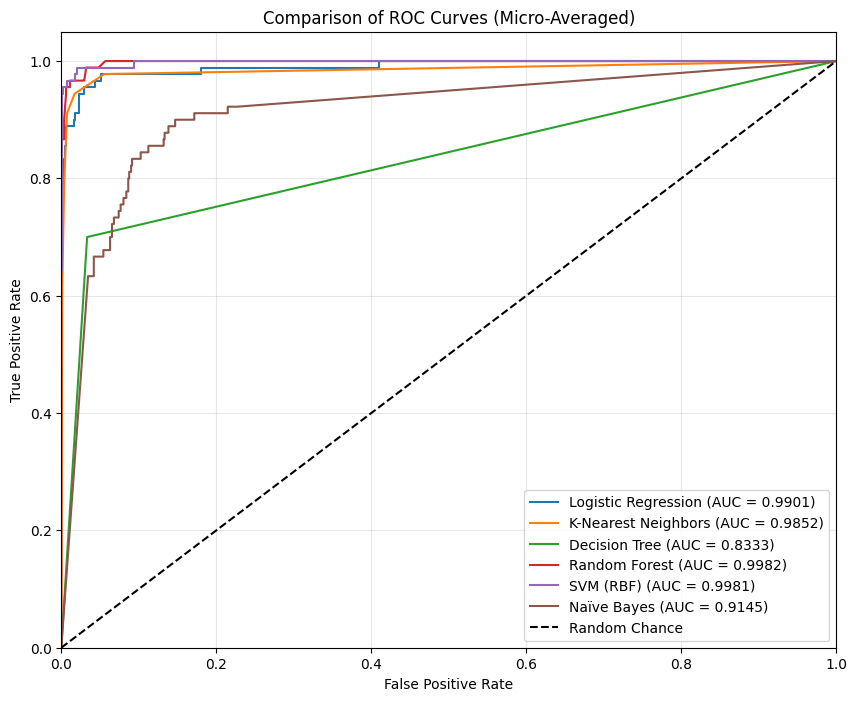

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# 1. Prepare labels for multi-class ROC
classes = np.unique(y)
y_val_bin = label_binarize(y_val, classes=classes)
n_classes = y_val_bin.shape[1]

# 2. Define models with the best hyperparameters found
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=15, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', C=1, probability=True, random_state=42),
    "Naïve Bayes": GaussianNB()
}

plt.figure(figsize=(10, 8))

# 3. Train models and plot each ROC curve
for name, model in models.items():
    model.fit(X_train, y_train)

    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_val)
    else: # For models without predict_proba
        y_score = model.decision_function(X_val)

    # Compute micro-average ROC curve and ROC area
    # (Flattening arrays to treat it as a binary classification task)
    fpr, tpr, _ = roc_curve(y_val_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# 4. Final plot formatting
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves (Micro-Averaged)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

4 **5 Fold-Cross Validitation**
--
---
The code performs automated model benchmarking and hyperparameter tuning to find the most accurate algorithm for the dataset.

Instead of a simple train/test split, the code uses cross_val_score with cv=5. It splits the data into 5 equal parts, training and testing the model 5 different times. This ensures the accuracy score isn't just a "lucky" result from one specific data split.

The results show the table of the mean accuracy and standard deviation for all six models.

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Dictionary to store results
results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
scores = cross_val_score(lr, X, y, cv=5)
results['Logistic Regression'] = (scores.mean(), scores.std())

# 2. K-Nearest Neighbors (Manual Tune k)
best_mean, best_std, best_k = 0, 0, 0
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5)
    if scores.mean() > best_mean:
        best_mean, best_std, best_k = scores.mean(), scores.std(), k
results[f'KNN (Best k={best_k})'] = (best_mean, best_std)

# 3. Decision Tree (Manual Tune depth)
best_mean, best_std, best_depth = 0, 0, 0
for d in range(1, 11):
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(dt, X, y, cv=5)
    if scores.mean() > best_mean:
        best_mean, best_std, best_depth = scores.mean(), scores.std(), d
results[f'Decision Tree (Best depth={best_depth})'] = (best_mean, best_std)

# 4. Random Forest (Manual Tune n_estimators)
best_mean, best_std, best_n = 0, 0, 0
for n in [10, 50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(rf, X, y, cv=5)
    if scores.mean() > best_mean:
        best_mean, best_std, best_n = scores.mean(), scores.std(), n
results[f'Random Forest (Best n={best_n})'] = (best_mean, best_std)

# 5. SVM with RBF Kernel
svm = SVC(kernel='rbf')
scores = cross_val_score(svm, X, y, cv=5)
results['SVM (RBF)'] = (scores.mean(), scores.std())

# 6. Naïve Bayes
nb = GaussianNB()
scores = cross_val_score(nb, X, y, cv=5)
results['Naïve Bayes'] = (scores.mean(), scores.std())

# --- Report Results ---
print(f"{'Model':<30} | {'Mean Accuracy':<15} | {'Std':<10}")
print("-" * 60)
for model, (mean, std) in results.items():
    print(f"{model:<30} | {mean:.4f}          | {std:.4f}")

Model                          | Mean Accuracy   | Std       
------------------------------------------------------------
Logistic Regression            | 0.8520          | 0.0260
KNN (Best k=1)                 | 0.8940          | 0.0180
Decision Tree (Best depth=9)   | 0.7075          | 0.0386
Random Forest (Best n=100)     | 0.9120          | 0.0081
SVM (RBF)                      | 0.9250          | 0.0196
Naïve Bayes                    | 0.5860          | 0.0346


**Comparison Table for all Models** (Accuracy, Precision, Recall, F1 and AUC-ROC)
--


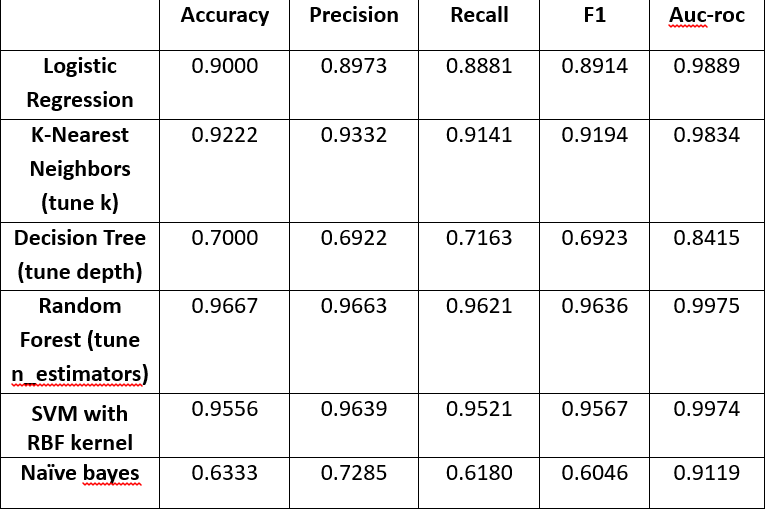